# Test Metrics

Evaluate the configured 3-channel and 5-channel `val_IoU` checkpoints on the held-out test split.

## Setup

In [1]:
from pathlib import Path
import sys

import numpy as np
import torch
from IPython.display import Markdown, display

CWD = Path.cwd()
if (CWD / "src").exists():
    REPO_ROOT = CWD
elif (CWD.parent / "src").exists():
    REPO_ROOT = CWD.parent
else:
    raise RuntimeError("Could not find repo root containing src/.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data import build_dataloaders
from src.evaluate import evaluate_test_metrics, load_checkpoint_model
from src.train import sync_class_config
from src.utils import get_device, load_config
from src.visualize import plot_confusion_matrix

device = get_device()
device

device(type='cuda')

## Load Config

In [2]:
metrics_config = load_config(REPO_ROOT / "configs" / "test_metrics.yaml")
class_names = metrics_config["class_names"]
ignore_index = metrics_config.get("metrics", {}).get("ignore_index", 255)
viz_config = metrics_config.get("visualization", {})
normalize_confusion_matrix = viz_config.get("normalize_confusion_matrix", True)
viz_output_dir = REPO_ROOT / viz_config.get("output_dir", "notebooks/outputs/test_metrics/")
viz_output_dir.mkdir(parents=True, exist_ok=True)

[(entry["name"], entry["label"], entry["checkpoint"]) for entry in metrics_config["models"]]

[('resnet34_unet_5ch',
  'ResNet34-UNet (5ch)',
  'notebooks/outputs/resnet34_unet_5ch_val_IoU/best.pt'),
 ('resnet34_unet_3ch',
  'ResNet34-UNet (3ch)',
  'notebooks/outputs/resnet34_unet_3ch_valIoU/best.pt'),
 ('convnext_tiny_3ch',
  'ConvNext-Tiny (3ch)',
  'notebooks/outputs/convnext_tiny_3ch_val_IoU/best.pt'),
 ('convnext_tiny_5ch',
  'ConvNext-Tiny (5ch)',
  'notebooks/outputs/convnext_tiny_5ch_val_IoU/best.pt'),
 ('dinov3_convnext_5ch',
  'DINOv3-ConvNext-Tiny (5ch)',
  'notebooks/outputs/dinov3_convnext_tiny_5ch_val_IoU/best.pt'),
 ('dinov3_convnext_3ch',
  'DINOv3-ConvNext-Tiny (3ch)',
  'notebooks/outputs/dinov3_convnext_tiny_3ch_val_IoU/best.pt')]

## Helpers

In [3]:
def markdown_table(rows, columns):
    header = "| " + " | ".join(label for _, label in columns) + " |"
    divider = "| " + " | ".join("---" for _ in columns) + " |"
    lines = [header, divider]
    for row in rows:
        values = []
        for key, _ in columns:
            value = row.get(key, "")
            if isinstance(value, float):
                value = "nan" if np.isnan(value) else f"{value:.4f}"
            values.append(str(value))
        lines.append("| " + " | ".join(values) + " |")
    display(Markdown("\n".join(lines)))


def evaluate_model_entry(entry):
    train_config = sync_class_config(load_config(REPO_ROOT / entry["config"]))
    train_config["model"]["in_channels"] = entry["in_channels"]
    train_config["model"]["num_classes"] = entry["num_classes"]
    train_config["data"]["channels"] = list(range(1, entry["in_channels"] + 1))
    train_config["data"]["num_classes"] = entry["num_classes"]

    _, _, test_loader = build_dataloaders(train_config["data"])
    model, checkpoint = load_checkpoint_model(
        REPO_ROOT / entry["checkpoint"],
        device=device,
        model_config=train_config["model"],
    )

    metrics = evaluate_test_metrics(
        model=model,
        dataloader=test_loader,
        num_classes=entry["num_classes"],
        device=device,
        ignore_index=ignore_index,
        class_names=class_names,
    )

    return {
        "entry": entry,
        "checkpoint": checkpoint,
        "metrics": metrics,
    }

## Run Evaluation

In [4]:
results = []
for entry in metrics_config["models"]:
    print(f"Evaluating {entry['label']} from {entry['checkpoint']}")
    results.append(evaluate_model_entry(entry))

len(results)

Evaluating ResNet34-UNet (5ch) from notebooks/outputs/resnet34_unet_5ch_val_IoU/best.pt


Evaluating test metrics: 100%|██████████| 4/4 [00:00<00:00, 10.49it/s]


Evaluating ResNet34-UNet (3ch) from notebooks/outputs/resnet34_unet_3ch_valIoU/best.pt


Evaluating test metrics: 100%|██████████| 4/4 [00:00<00:00, 18.31it/s]


Evaluating ConvNext-Tiny (3ch) from notebooks/outputs/convnext_tiny_3ch_val_IoU/best.pt


...

Evaluating test metrics: 100%|██████████| 4/4 [00:00<00:00, 17.54it/s]


Evaluating DINOv3-ConvNext-Tiny (3ch) from notebooks/outputs/dinov3_convnext_tiny_3ch_val_IoU/best.pt


Loading weights:   0%|          | 0/180 [00:00<?, ?it/s]

Evaluating test metrics: 100%|██████████| 4/4 [00:00<00:00, 18.89it/s]


6

## Summary Metrics

In [5]:
summary_rows = []
for result in results:
    entry = result["entry"]
    metrics = result["metrics"]
    summary_rows.append({
        "model": entry["label"],
        "pixels": metrics["num_pixels"],
        "pixel_accuracy": metrics["pixel_accuracy"],
        "mIoU": metrics["mIoU"],
        "mean_dice": metrics["mean_dice"],
        "mAP": metrics["mAP"],
    })

markdown_table(
    summary_rows,
    [
        ("model", "Model"),
        ("pixels", "Pixels"),
        ("pixel_accuracy", "Pixel Acc"),
        ("mIoU", "mIoU"),
        ("mean_dice", "Mean Dice"),
        ("mAP", "mAP"),
    ],
)

| Model | Pixels | Pixel Acc | mIoU | Mean Dice | mAP |
| --- | --- | --- | --- | --- | --- |
| ResNet34-UNet (5ch) | 6553600 | 0.7172 | 0.4361 | 0.5540 | 0.6374 |
| ResNet34-UNet (3ch) | 6553600 | 0.7286 | 0.4605 | 0.5885 | 0.6385 |
| ConvNext-Tiny (3ch) | 6553600 | 0.6925 | 0.4466 | 0.5710 | 0.6907 |
| ConvNext-Tiny (5ch) | 6553600 | 0.7195 | 0.4837 | 0.6254 | 0.7230 |
| DINOv3-ConvNext-Tiny (5ch) | 6553600 | 0.7195 | 0.4914 | 0.6056 | 0.7356 |
| DINOv3-ConvNext-Tiny (3ch) | 6553600 | 0.7246 | 0.4782 | 0.6041 | 0.6799 |

## Per-Class Metrics

In [6]:
for result in results:
    entry = result["entry"]
    display(Markdown(f"### {entry['label']}"))
    markdown_table(
        result["metrics"]["class_rows"],
        [
            ("class_id", "ID"),
            ("class_name", "Class"),
            ("support_pixels", "Support"),
            ("predicted_pixels", "Predicted"),
            ("iou", "IoU"),
            ("dice", "Dice"),
            ("average_precision", "AP"),
        ],
    )

### ResNet34-UNet (5ch)

| ID | Class | Support | Predicted | IoU | Dice | AP |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 3160054 | 0.6599 | 0.7951 | 0.8443 |
| 1 | Bare (Non-vegetated) | 270954 | 96337 | 0.0331 | 0.0642 | 0.1363 |
| 2 | Woody Vegetation | 1656028 | 1543289 | 0.7027 | 0.8254 | 0.9175 |
| 3 | Agriculture | 882872 | 1161097 | 0.6852 | 0.8132 | 0.9456 |
| 4 | Herbaceous Vegetation | 1066132 | 319485 | 0.1688 | 0.2888 | 0.4903 |
| 5 | Water | 444298 | 273338 | 0.3671 | 0.5371 | 0.4905 |

### ResNet34-UNet (3ch)

| ID | Class | Support | Predicted | IoU | Dice | AP |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 2928375 | 0.6889 | 0.8158 | 0.8363 |
| 1 | Bare (Non-vegetated) | 270954 | 88690 | 0.0590 | 0.1113 | 0.1669 |
| 2 | Woody Vegetation | 1656028 | 1940507 | 0.6930 | 0.8186 | 0.9116 |
| 3 | Agriculture | 882872 | 629565 | 0.6559 | 0.7922 | 0.9224 |
| 4 | Herbaceous Vegetation | 1066132 | 719496 | 0.2733 | 0.4293 | 0.4015 |
| 5 | Water | 444298 | 246967 | 0.3928 | 0.5640 | 0.5920 |

### ConvNext-Tiny (3ch)

...

| ID | Class | Support | Predicted | IoU | Dice | AP |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 2973550 | 0.6397 | 0.7803 | 0.7907 |
| 1 | Bare (Non-vegetated) | 270954 | 59729 | 0.2195 | 0.3600 | 0.7192 |
| 2 | Woody Vegetation | 1656028 | 1739961 | 0.6456 | 0.7846 | 0.9004 |
| 3 | Agriculture | 882872 | 782752 | 0.7574 | 0.8620 | 0.8819 |
| 4 | Herbaceous Vegetation | 1066132 | 749328 | 0.2720 | 0.4276 | 0.4236 |
| 5 | Water | 444298 | 248280 | 0.3681 | 0.5381 | 0.6225 |

### DINOv3-ConvNext-Tiny (5ch)

| ID | Class | Support | Predicted | IoU | Dice | AP |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 2635632 | 0.6454 | 0.7845 | 0.8994 |
| 1 | Bare (Non-vegetated) | 270954 | 4935 | 0.0021 | 0.0041 | 0.3850 |
| 2 | Woody Vegetation | 1656028 | 1784575 | 0.6248 | 0.7690 | 0.8902 |
| 3 | Agriculture | 882872 | 752430 | 0.8006 | 0.8892 | 0.9637 |
| 4 | Herbaceous Vegetation | 1066132 | 1056867 | 0.2857 | 0.4444 | 0.4068 |
| 5 | Water | 444298 | 319161 | 0.5902 | 0.7423 | 0.8687 |

### DINOv3-ConvNext-Tiny (3ch)

| ID | Class | Support | Predicted | IoU | Dice | AP |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | Built (Non-vegetated) | 2233316 | 2901637 | 0.6350 | 0.7767 | 0.8605 |
| 1 | Bare (Non-vegetated) | 270954 | 16288 | 0.0594 | 0.1121 | 0.1809 |
| 2 | Woody Vegetation | 1656028 | 1747384 | 0.6544 | 0.7911 | 0.8692 |
| 3 | Agriculture | 882872 | 773711 | 0.7958 | 0.8863 | 0.8981 |
| 4 | Herbaceous Vegetation | 1066132 | 839269 | 0.3051 | 0.4675 | 0.4212 |
| 5 | Water | 444298 | 275311 | 0.4195 | 0.5910 | 0.8493 |

## 3ch vs 5ch Deltas

In [7]:
result_by_name = {result["entry"]["name"]: result for result in results}
model_pairs = [
    ("ResNet34-UNet", "resnet34_unet_3ch", "resnet34_unet_5ch"),
    ("ConvNext-Tiny", "convnext_tiny_3ch", "convnext_tiny_5ch"),
    ("DINOv3-ConvNext-Tiny", "dinov3_convnext_3ch", "dinov3_convnext_5ch"),
]

delta_rows = []
for family, three_name, five_name in model_pairs:
    three = result_by_name[three_name]["metrics"]
    five = result_by_name[five_name]["metrics"]
    delta_rows.append({
        "family": family,
        "mIoU_3ch": three["mIoU"],
        "mIoU_5ch": five["mIoU"],
        "delta_mIoU": five["mIoU"] - three["mIoU"],
        "mAP_3ch": three["mAP"],
        "mAP_5ch": five["mAP"],
        "delta_mAP": five["mAP"] - three["mAP"],
        "pixel_acc_3ch": three["pixel_accuracy"],
        "pixel_acc_5ch": five["pixel_accuracy"],
        "delta_pixel_acc": five["pixel_accuracy"] - three["pixel_accuracy"],
        "delta_mean_dice": five["mean_dice"] - three["mean_dice"],
    })

markdown_table(
    delta_rows,
    [
        ("family", "Model Family"),
        ("mIoU_3ch", "3ch mIoU"),
        ("mIoU_5ch", "5ch mIoU"),
        ("delta_mIoU", "Delta mIoU"),
        ("mAP_3ch", "3ch mAP"),
        ("mAP_5ch", "5ch mAP"),
        ("delta_mAP", "Delta mAP"),
        ("delta_pixel_acc", "Delta Pixel Acc"),
        ("delta_mean_dice", "Delta Mean Dice"),
    ],
)

| Model Family | 3ch mIoU | 5ch mIoU | Delta mIoU | 3ch mAP | 5ch mAP | Delta mAP | Delta Pixel Acc | Delta Mean Dice |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| ResNet34-UNet | 0.4605 | 0.4361 | -0.0243 | 0.6385 | 0.6374 | -0.0011 | -0.0114 | -0.0346 |
| ConvNext-Tiny | 0.4466 | 0.4837 | 0.0371 | 0.6907 | 0.7230 | 0.0324 | 0.0270 | 0.0544 |
| DINOv3-ConvNext-Tiny | 0.4782 | 0.4914 | 0.0132 | 0.6799 | 0.7356 | 0.0558 | -0.0051 | 0.0015 |

## Per-Class 3ch vs 5ch Deltas

In [ ]:
per_class_delta_rows = []
for family, three_name, five_name in model_pairs:
    three_rows = result_by_name[three_name]["metrics"]["class_rows"]
    five_rows = result_by_name[five_name]["metrics"]["class_rows"]
    for three_row, five_row in zip(three_rows, five_rows):
        per_class_delta_rows.append({
            "family": family,
            "class_name": five_row["class_name"],
            "delta_iou": five_row["iou"] - three_row["iou"],
            "delta_dice": five_row["dice"] - three_row["dice"],
            "delta_ap": five_row["average_precision"] - three_row["average_precision"],
        })

print("Delta is computed as (5-channel) - (3-channel), so positive means the 5-channel model performed better.")
markdown_table(
    per_class_delta_rows,
    [
        ("family", "Model Family"),
        ("class_name", "Class"),
        ("delta_iou", "Delta IoU"),
        ("delta_dice", "Delta Dice"),
        ("delta_ap", "Delta AP"),
    ],
)

| Model Family | Class | Delta IoU | Delta Dice | Delta AP |
| --- | --- | --- | --- | --- |
| ResNet34-UNet | Built (Non-vegetated) | -0.0290 | -0.0207 | 0.0080 |
| ResNet34-UNet | Bare (Non-vegetated) | -0.0258 | -0.0472 | -0.0307 |
| ResNet34-UNet | Woody Vegetation | 0.0097 | 0.0068 | 0.0059 |
| ResNet34-UNet | Agriculture | 0.0293 | 0.0210 | 0.0231 |
| ResNet34-UNet | Herbaceous Vegetation | -0.1045 | -0.1405 | 0.0887 |
| ResNet34-UNet | Water | -0.0257 | -0.0270 | -0.1015 |
| ConvNext-Tiny | Built (Non-vegetated) | 0.0512 | 0.0393 | -0.0304 |
| ConvNext-Tiny | Bare (Non-vegetated) | 0.2121 | 0.3453 | 0.4019 |
| ConvNext-Tiny | Woody Vegetation | 0.0430 | 0.0326 | 0.0308 |
| ConvNext-Tiny | Agriculture | -0.0011 | -0.0007 | 0.0081 |
| ConvNext-Tiny | Herbaceous Vegetation | -0.0298 | -0.0360 | 0.0301 |
| ConvNext-Tiny | Water | -0.0526 | -0.0541 | -0.2462 |
| DINOv3-ConvNext-Tiny | Built (Non-vegetated) | 0.0104 | 0.0077 | 0.0388 |
| DINOv3-ConvNext-Tiny | Bare (Non-vegetated) | -0.0573 | -0.1080 | 0.2042 |
| DINOv3-ConvNext-Tiny | Woody Vegetation | -0.0296 | -0.0220 | 0.0210 |
| DINOv3-ConvNext-Tiny | Agriculture | 0.0047 | 0.0029 | 0.0656 |
| DINOv3-ConvNext-Tiny | Herbaceous Vegetation | -0.0194 | -0.0232 | -0.0144 |
| DINOv3-ConvNext-Tiny | Water | 0.1707 | 0.1512 | 0.0194 |

## Confusion Matrices

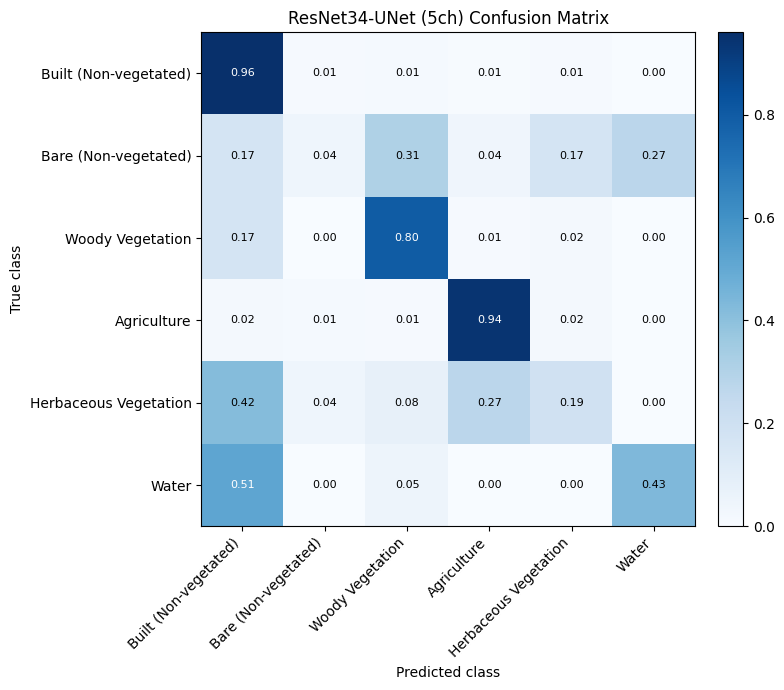

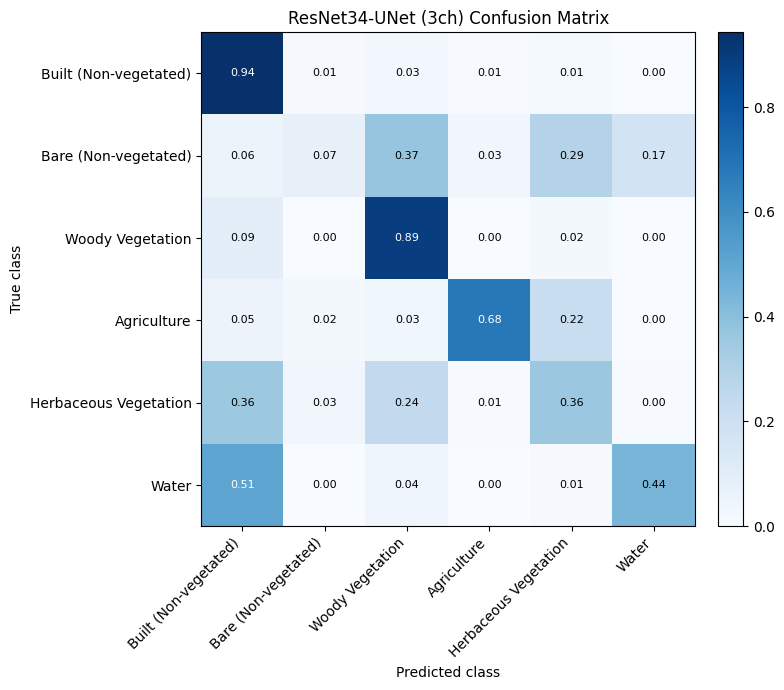

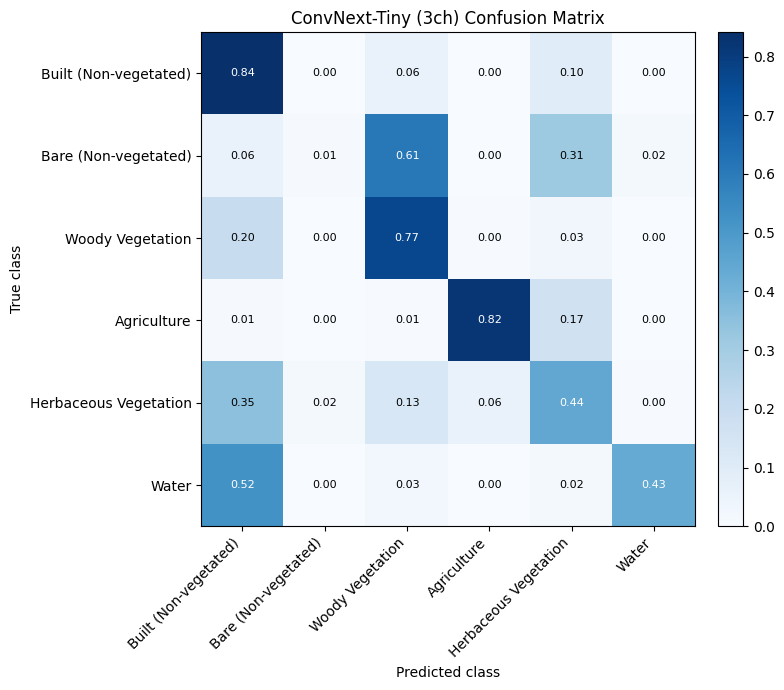

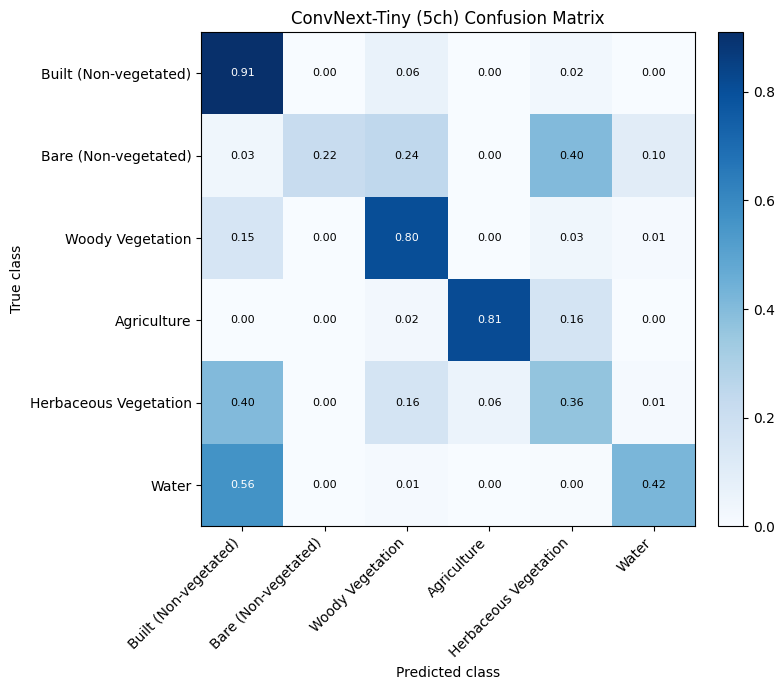

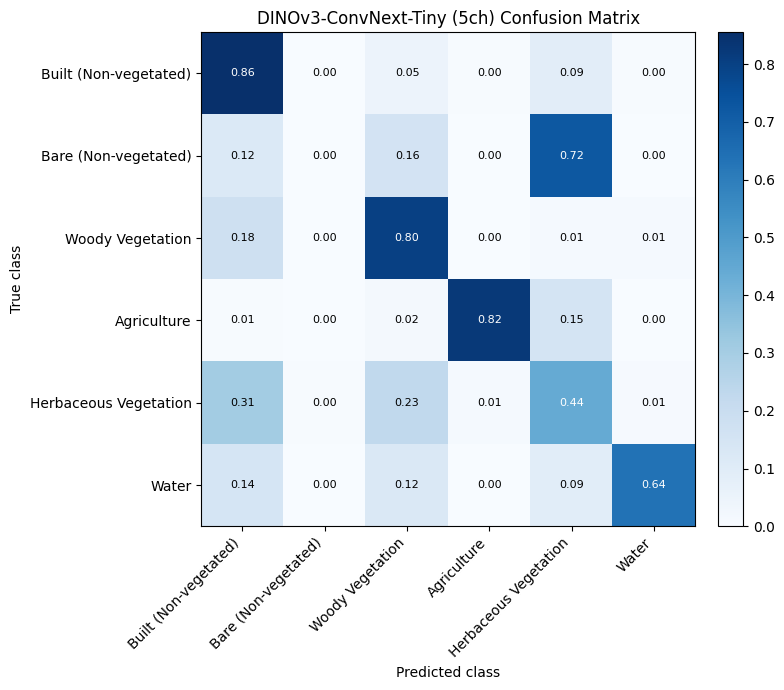

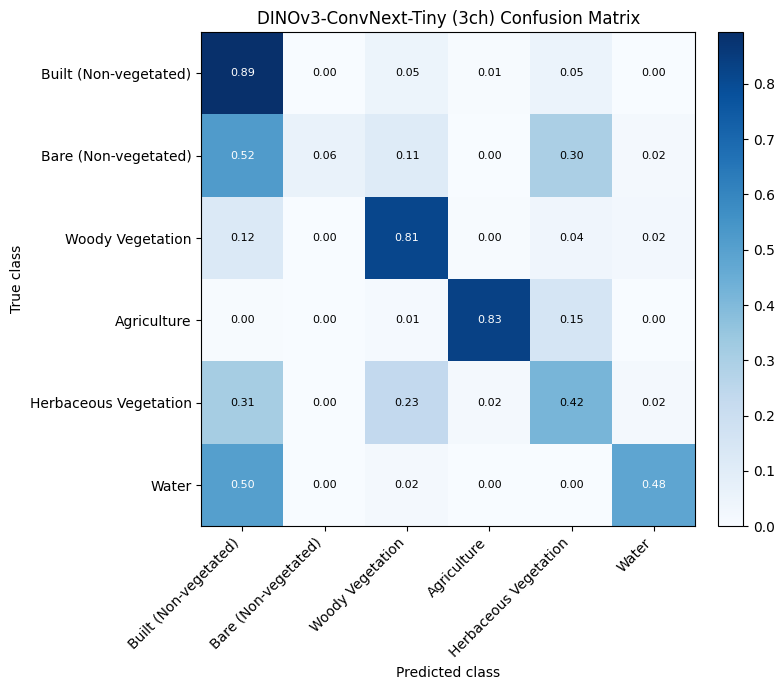

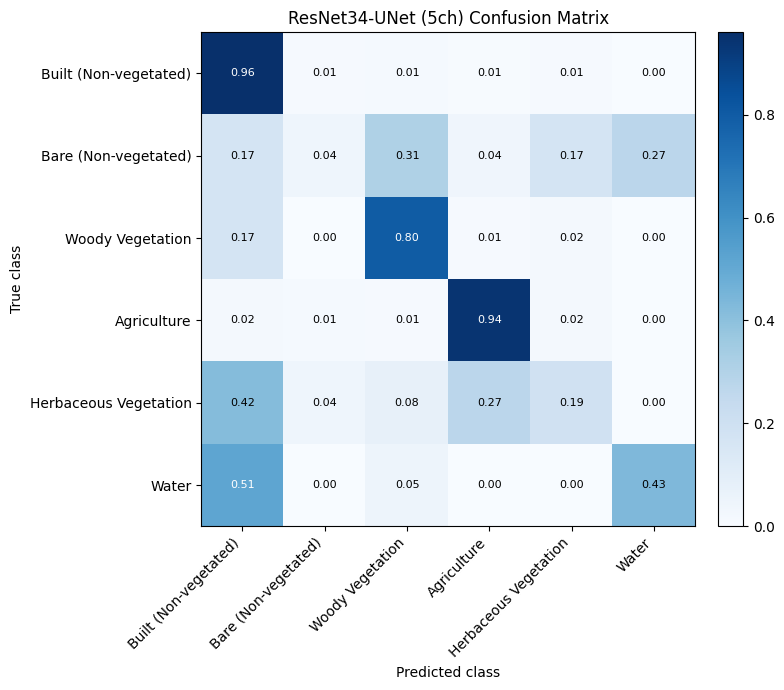

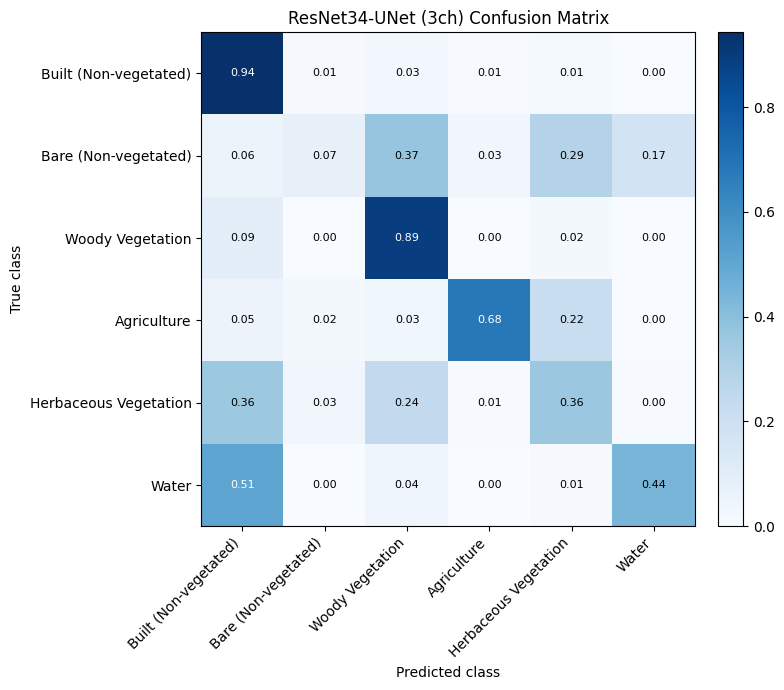

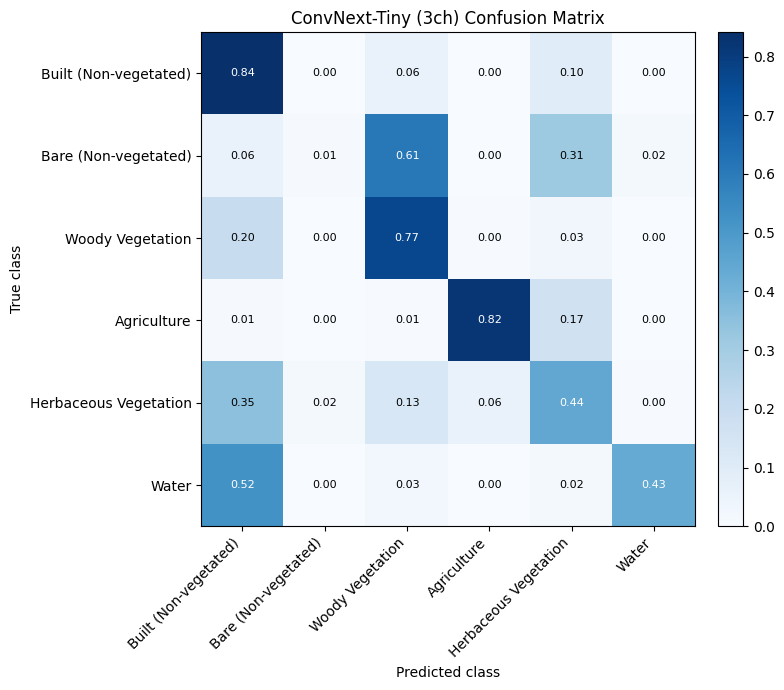

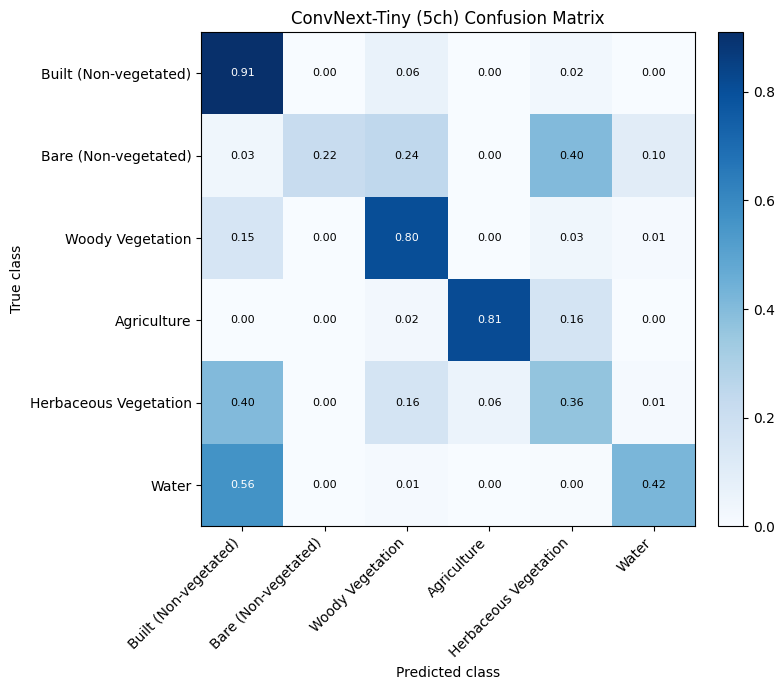

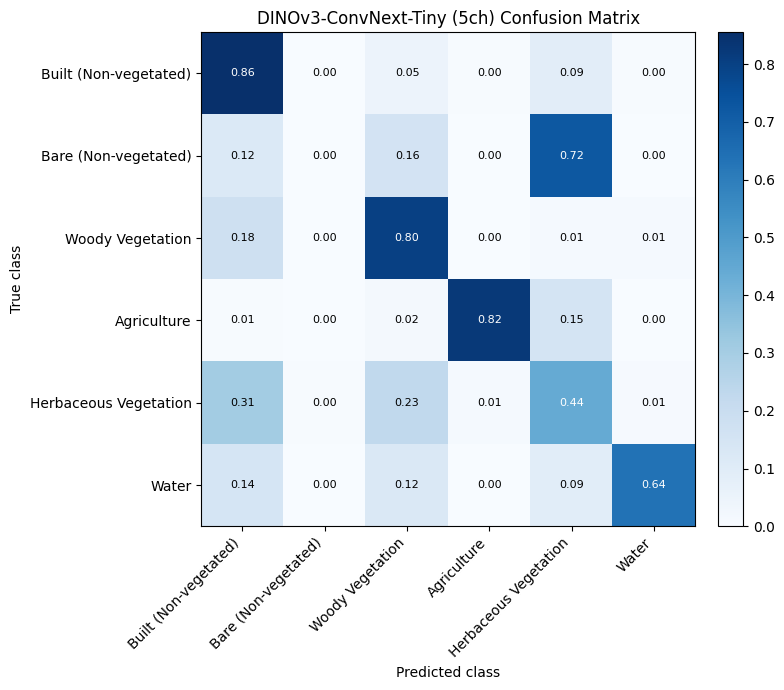

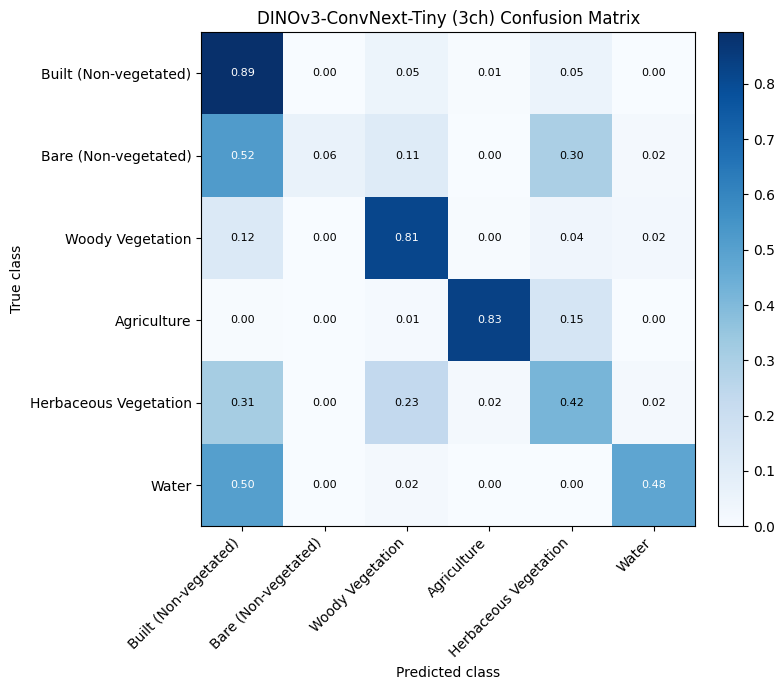

In [9]:
for result in results:
    entry = result["entry"]
    fig = plot_confusion_matrix(
        result["metrics"]["confusion_matrix"],
        class_names=class_names,
        normalize=normalize_confusion_matrix,
        title=f"{entry['label']} Confusion Matrix",
    )
    fig.savefig(viz_output_dir / f"{entry['name']}_confusion_matrix.png", dpi=viz_config.get("dpi", 150), bbox_inches="tight")
    display(fig)